In [9]:
%load_ext autoreload
%autoreload 2
import numpy as np
import geopandas as gpd
import pandas as pd
import os
from tile import tile_sampler

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
os.getcwd()
os.chdir(r'c:\\Users\\solan\\OneDrive\\Desktop\\IntrotoPython\\FinalProj\\cropfield-polygonization\\data')

zambia_shp = gpd.read_parquet(r'zambia_2023_attributed.parquet')

In [11]:
test_poly = tile_sampler(zambia_shp, 'tile_id', 'area_m2', 1000, None)

In [18]:
print(test_poly[["compactness", "shape_index", "interior_edge", "fractal_dim"]].isnull().sum())

compactness      0
shape_index      0
interior_edge    0
fractal_dim      0
dtype: int64


In [ ]:
test_poly.describe()

# Look at the bottom 25% compactness, top 25% shape index, top 25% interior edge, top 25% fractal dim

zam_filt = test_poly[(test_poly["compactness"] <= test_poly["compactness"].quantile(0.25)) & (test_poly["shape_index"] >= test_poly["shape_index"].quantile(0.75)) & (test_poly["interior_edge"] >= test_poly["interior_edge"].quantile(0.75)) & (test_poly["fractal_dim"] >= test_poly["fractal_dim"].quantile(0.75))]

In [27]:
# reproject to WGS84 UTM 35S
zam_filt = zam_filt.to_crs(32735)

In [35]:
display(zam_filt['geometry'].length)
zam_filt.info()

334         90.723773
427        124.801717
589        175.940342
820         79.328253
853        330.370118
              ...    
8327323    124.704337
8327377     85.870594
8327381    138.495124
8327517    191.010716
8327609    128.429250
Length: 19208, dtype: float64

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 19208 entries, 334 to 8327609
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area_m2        19208 non-null  float64 
 1   area_ha        19208 non-null  float64 
 2   perimeter_m    19208 non-null  float64 
 3   compactness    19208 non-null  float64 
 4   shape_index    19208 non-null  float64 
 5   interior_edge  19208 non-null  float64 
 6   fractal_dim    19208 non-null  float64 
 7   tile_id        19208 non-null  float64 
 8   polygon_index  19208 non-null  float64 
 9   polygon_id     19208 non-null  float64 
 10  geometry       19208 non-null  geometry
 11  geometry_test  19208 non-null  geometry
dtypes: float64(10), geometry(2)
memory usage: 1.9 MB


In [29]:
# geopandas buffer function
zam_filt['geometry_test'] = zam_filt['geometry'].buffer(-2)

zam_filt

,area_m2,area_ha,perimeter_m,compactness,shape_index,interior_edge,fractal_dim,tile_id,polygon_index,polygon_id,geometry,geometry_test
334,278.122474,0.027812,93.941514,0.396033,1.589039,0.337770,1.614294,872362.0,98.0,8.723620e+11,"POLYGON ((448085.884 8633592.828, 448085.705 8...","POLYGON ((448074.291 8633590.816, 448074.302 8..."
427,421.461351,0.042146,119.912308,0.368333,1.647707,0.284516,1.584042,872362.0,191.0,8.723620e+11,"POLYGON ((448869.807 8630062.03, 448921.476 86...","POLYGON ((448870.559 8630059.94, 448919.479 86..."
589,899.471465,0.089947,172.273798,0.380854,1.620394,0.191528,1.514034,872362.0,353.0,8.723620e+11,"POLYGON ((450364.87 8633450.207, 450383.89 863...","MULTIPOLYGON (((450362.343 8633449.245, 450330..."
820,146.242156,0.014624,76.340918,0.315332,1.780804,0.522017,1.739209,883528.0,80.0,8.835280e+11,"POLYGON ((266450.139 8528534.861, 266485.331 8...","POLYGON ((266466.211 8528535.501, 266483.352 8..."
853,2497.466355,0.249747,328.907781,0.290109,1.856604,0.131697,1.481722,883528.0,113.0,8.835280e+11,"POLYGON ((266676.331 8529652.351, 266687.151 8...","MULTIPOLYGON (((266673.824 8529651.562, 266662..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8327323,538.871375,0.053887,127.528975,0.416368,1.549749,0.236659,1.541732,852161.0,1709.0,8.521610e+11,"POLYGON ((994054.16 8904971.968, 994067.8 8904...","POLYGON ((994056.112 8904968.394, 994065.96 89..."
8327377,174.547181,0.017455,88.157894,0.282228,1.882348,0.505066,1.735358,852161.0,1763.0,8.521610e+11,"POLYGON ((994197.667 8901347.092, 994189.153 8...","MULTIPOLYGON (((994195.348 8901346.791, 994189..."
8327381,527.437230,0.052744,137.656381,0.349774,1.690854,0.260991,1.571390,852161.0,1767.0,8.521610e+11,"POLYGON ((994284.272 8901445.785, 994300.697 8...","MULTIPOLYGON (((994273.972 8901423.655, 994264..."
8327517,1127.266527,0.112727,190.675626,0.389624,1.602053,0.169149,1.494283,852161.0,1903.0,8.521610e+11,"POLYGON ((994718.073 8901184.685, 994737.06 89...","POLYGON ((994717.212 8901182.697, 994734.84 89..."


In [64]:
# finding shorter dimension of every polygon and halving it (approximation for max buffer distance)
zam_filt['min_len'] = zam_filt.geometry.apply(
    lambda g: -(min(g.bounds[2] - g.bounds[0], g.bounds[3] - g.bounds[1]) / 2)
)

delta = -.5 # buffer step


for idx, row in zam_filt.iterrows():
    current_buff = 0
    while current_buff >= row['min_len']: 
        current_buff += delta
        buffered = row['geometry'].buffer(current_buff)
        if buffered.geom_type == 'MultiPolygon':
            geoms = list(buffered.geoms) # extracting buffers
            print(f"Split happened for row {idx} at buffer distance {current_buff}.")
            zam_filt.at[idx, 'geometry_test'] = buffered
            zam_filt.at[idx, 'sdist'] = current_buff
            zam_filt.at[idx, 'buffer_geom1'] = geoms[0]
            zam_filt.at[idx, 'buffer_geom2'] = geoms[1]
            break  
    else:
        print(f"No split for row {idx} within dimension limit")
 

No split for row 334 within dimension limit
Split happened for row 427 at buffer distance -2.5.
Split happened for row 589 at buffer distance -1.5.
No split for row 820 within dimension limit
Split happened for row 853 at buffer distance -1.5.
Split happened for row 854 at buffer distance -2.0.
Split happened for row 904 at buffer distance -5.0.
No split for row 5939 within dimension limit
Split happened for row 5982 at buffer distance -2.5.
No split for row 6052 within dimension limit
No split for row 6059 within dimension limit
Split happened for row 6144 at buffer distance -2.0.
No split for row 6171 within dimension limit
Split happened for row 6173 at buffer distance -6.5.
Split happened for row 6181 at buffer distance -6.0.
No split for row 6187 within dimension limit
Split happened for row 6229 at buffer distance -2.0.
Split happened for row 7152 at buffer distance -8.5.
Split happened for row 7206 at buffer distance -7.5.
Split happened for row 7211 at buffer distance -6.5.
Spl

In [65]:
zam_filt

,area_m2,area_ha,perimeter_m,compactness,shape_index,interior_edge,fractal_dim,tile_id,polygon_index,polygon_id,geometry,geometry_test,min_len,sdist,buffer_geom1,buffer_geom2
334,278.122474,0.027812,93.941514,0.396033,1.589039,0.337770,1.614294,872362.0,98.0,8.723620e+11,"POLYGON ((448085.884 8633592.828, 448085.705 8...","POLYGON ((448074.291 8633590.816, 448074.302 8...",-6.800614,NaN,NaN,NaN
427,421.461351,0.042146,119.912308,0.368333,1.647707,0.284516,1.584042,872362.0,191.0,8.723620e+11,"POLYGON ((448869.807 8630062.03, 448921.476 86...","MULTIPOLYGON (((448870.747 8630059.417, 448874...",-6.895837,-2.5,"POLYGON ((448870.7471449071 8630059.417193107,...",POLYGON ((448879.52907449054 8630058.492413895...
589,899.471465,0.089947,172.273798,0.380854,1.620394,0.191528,1.514034,872362.0,353.0,8.723620e+11,"POLYGON ((450364.87 8633450.207, 450383.89 863...","MULTIPOLYGON (((450364.154 8633448.888, 450330...",-15.175811,-1.5,POLYGON ((450364.15396784496 8633448.887874793...,"POLYGON ((450365.4506987538 8633448.824718364,..."
820,146.242156,0.014624,76.340918,0.315332,1.780804,0.522017,1.739209,883528.0,80.0,8.835280e+11,"POLYGON ((266450.139 8528534.861, 266485.331 8...","POLYGON ((266466.211 8528535.501, 266483.352 8...",-4.304399,NaN,NaN,NaN
853,2497.466355,0.249747,328.907781,0.290109,1.856604,0.131697,1.481722,883528.0,113.0,8.835280e+11,"POLYGON ((266676.331 8529652.351, 266687.151 8...","MULTIPOLYGON (((266675.535 8529651.08, 266675....",-25.192013,-1.5,"POLYGON ((266675.5354214908 8529651.079915697,...","POLYGON ((266676.9434934435 8529650.961647086,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8327323,538.871375,0.053887,127.528975,0.416368,1.549749,0.236659,1.541732,852161.0,1709.0,8.521610e+11,"POLYGON ((994054.16 8904971.968, 994067.8 8904...","MULTIPOLYGON (((994058.064 8904964.819, 994064...",-13.620544,-4.0,"POLYGON ((994058.0642397491 8904964.819179898,...","POLYGON ((994067.0057859689 8904944.55963247, ..."
8327377,174.547181,0.017455,88.157894,0.282228,1.882348,0.505066,1.735358,852161.0,1763.0,8.521610e+11,"POLYGON ((994197.667 8901347.092, 994189.153 8...","MULTIPOLYGON (((994195.348 8901346.791, 994189...",-11.131828,-2.0,"POLYGON ((994195.348353187 8901346.791373504, ...","POLYGON ((994198.3090144271 8901350.524724662,..."
8327381,527.437230,0.052744,137.656381,0.349774,1.690854,0.260991,1.571390,852161.0,1767.0,8.521610e+11,"POLYGON ((994284.272 8901445.785, 994300.697 8...","MULTIPOLYGON (((994275.313 8901422.655, 994263...",-15.217349,-1.5,"POLYGON ((994275.3125457475 8901422.654599614,...","POLYGON ((994278.059638289 8901419.446213271, ..."
8327517,1127.266527,0.112727,190.675626,0.389624,1.602053,0.169149,1.494283,852161.0,1903.0,8.521610e+11,"POLYGON ((994718.073 8901184.685, 994737.06 89...","MULTIPOLYGON (((994705.818 8901187.371, 994705...",-30.919917,-5.0,"POLYGON ((994705.8182948178 8901187.371084435,...","POLYGON ((994705.831564893 8901187.357332611, ..."


In [ ]:
   ## find where the two separate polygons are closest, this is where
    ## the internal buffering pinched off into two polygons.

from shapely.ops import nearest_points
from shapely.ops import split
from shapely import LineString

for idx, row in zam_filt.iterrows():
    if pd.isna(row['sdist']):
        continue
    else:
        p1, p2 = nearest_points(row['buffer_geom1'], row['buffer_geom2'])
        zam_filt.at[idx, 'pinch1'] = p1
        zam_filt.at[idx, 'pinch2'] = p2
        zam_filt.at[idx, 'line'] = LineString([p1, p2])
        line_buff = row['line'].buffer(abs(row['sdist']))
        zam_filt.at[idx, 'line_buff'] = line_buff

        

In [ ]:
from math import sqrt
from shapely.ops import Point
from shapely.ops import snap

for idx, row in zam_filt.iterrows():
    if pd.isna(row['sdist']):
        continue
    else:
        dx = row['pinch2'].x - row['pinch1'].x
        dy = row['pinch2'].y - row['pinch1'].y
        length = sqrt(dx**2 + dy**2)
        dx, dy = dx/length * abs(row['sdist'])*20, dy/length * abs(row['sdist'])*20 # normalize to unit vector for x and y directions, multiple by sdist * 2 
        new_p1 = Point(row['pinch1'].x - dx, row['pinch1'].y - dy)
        new_p2 = Point(row['pinch2'].x + dx, row['pinch2'].y + dy)
        new_line = LineString([new_p1, new_p2])
        new_line = snap(new_line, row['geometry'], tolerance=1e-6)
        cut = split(row['geometry'], new_line)
        parts = list(cut.geoms)
        print(f"Row {idx}: {len(parts)} parts")
    
    if len(parts) < 2:
        gpd.GeoDataFrame(geometry=[row['geometry'], new_line]).plot(color=['blue','red'])
        continue
    
    zam_filt.at[idx, 'split_geom1'] = parts[0]
    zam_filt.at[idx, 'split_geom2'] = parts[1]
        parts = list(cut.geoms)
        zam_filt.at[idx, 'split_geom1'] = parts[0]
        zam_filt.at[idx, 'split_geom2'] = parts[1]


IndexError: list index out of range

In [88]:
zam_filt
    

,area_m2,area_ha,perimeter_m,compactness,shape_index,interior_edge,fractal_dim,tile_id,polygon_index,polygon_id,geometry,geometry_test,min_len,sdist,buffer_geom1,buffer_geom2,pinch1,pinch2,line,line_buff
334,278.122474,0.027812,93.941514,0.396033,1.589039,0.337770,1.614294,872362.0,98.0,8.723620e+11,"POLYGON ((448085.884 8633592.828, 448085.705 8...","POLYGON ((448074.291 8633590.816, 448074.302 8...",-6.800614,NaN,NaN,NaN,NaN,NaN,NaN,NaN
427,421.461351,0.042146,119.912308,0.368333,1.647707,0.284516,1.584042,872362.0,191.0,8.723620e+11,"POLYGON ((448869.807 8630062.03, 448921.476 86...","MULTIPOLYGON (((448870.747 8630059.417, 448874...",-6.895837,-2.5,"POLYGON ((448870.7471449071 8630059.417193107,...",POLYGON ((448879.52907449054 8630058.492413895...,POINT (448874.64680089464 8630059.00654067),POINT (448879.52907449054 8630058.492413895),LINESTRING (448874.64680089464 8630059.0065406...,"POLYGON ((448879.79088881426 8630060.97866675,..."
589,899.471465,0.089947,172.273798,0.380854,1.620394,0.191528,1.514034,872362.0,353.0,8.723620e+11,"POLYGON ((450364.87 8633450.207, 450383.89 863...","MULTIPOLYGON (((450364.154 8633448.888, 450330...",-15.175811,-1.5,POLYGON ((450364.15396784496 8633448.887874793...,"POLYGON ((450365.4506987538 8633448.824718364,...",POINT (450364.15396784496 8633448.887874793),POINT (450365.4506987538 8633448.824718364),LINESTRING (450364.15396784496 8633448.8878747...,POLYGON ((450365.52366877615 8633450.322942438...
820,146.242156,0.014624,76.340918,0.315332,1.780804,0.522017,1.739209,883528.0,80.0,8.835280e+11,"POLYGON ((266450.139 8528534.861, 266485.331 8...","POLYGON ((266466.211 8528535.501, 266483.352 8...",-4.304399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
853,2497.466355,0.249747,328.907781,0.290109,1.856604,0.131697,1.481722,883528.0,113.0,8.835280e+11,"POLYGON ((266676.331 8529652.351, 266687.151 8...","MULTIPOLYGON (((266675.535 8529651.08, 266675....",-25.192013,-1.5,"POLYGON ((266675.5354214908 8529651.079915697,...","POLYGON ((266676.9434934435 8529650.961647086,...",POINT (266675.5415817375 8529651.076484295),POINT (266676.9434934435 8529650.961647086),LINESTRING (266675.5415817375 8529651.07648429...,POLYGON ((266677.06595535355 8529652.456639756...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8327323,538.871375,0.053887,127.528975,0.416368,1.549749,0.236659,1.541732,852161.0,1709.0,8.521610e+11,"POLYGON ((994054.16 8904971.968, 994067.8 8904...","MULTIPOLYGON (((994058.064 8904964.819, 994064...",-13.620544,-4.0,"POLYGON ((994058.0642397491 8904964.819179898,...","POLYGON ((994067.0057859689 8904944.55963247, ...",POINT (994066.2572826016 8904946.931111846),POINT (994067.0057859689 8904944.55963247),LINESTRING (994066.2572826016 8904946.93111184...,"POLYGON ((994070.8202943471 8904945.763595024,..."
8327377,174.547181,0.017455,88.157894,0.282228,1.882348,0.505066,1.735358,852161.0,1763.0,8.521610e+11,"POLYGON ((994197.667 8901347.092, 994189.153 8...","MULTIPOLYGON (((994195.348 8901346.791, 994189...",-11.131828,-2.0,"POLYGON ((994195.348353187 8901346.791373504, ...","POLYGON ((994198.3090144271 8901350.524724662,...",POINT (994195.348353187 8901346.791373504),POINT (994198.3090144271 8901350.524724662),LINESTRING (994195.348353187 8901346.791373504...,"POLYGON ((994196.7419633961 8901351.767443884,..."
8327381,527.437230,0.052744,137.656381,0.349774,1.690854,0.260991,1.571390,852161.0,1767.0,8.521610e+11,"POLYGON ((994284.272 8901445.785, 994300.697 8...","MULTIPOLYGON (((994275.313 8901422.655, 994263...",-15.217349,-1.5,"POLYGON ((994275.3125457475 8901422.654599614,...","POLYGON ((994278.059638289 8901419.446213271, ...",POINT (994275.3125457475 8901422.654599614),POINT (994278.059638289 8901419.446213271),LINESTRING (994275.3125457475 8901422.65459961...,"POLYGON ((994279.1990411984 8901420.421795666,..."
8327517,1127.266527,0.112727,190.675626,0.389624,1.602053,0.169149,1.494283,852161.0,1903.0,8.521610e+11,"POLYGON ((994718.073 8901184.685, 994737.06 8

In [80]:
zam_filt

,area_m2,area_ha,perimeter_m,compactness,shape_index,interior_edge,fractal_dim,tile_id,polygon_index,polygon_id,geometry,geometry_test,min_len,sdist,buffer_geom1,buffer_geom2,pinch1,pinch2,line
334,278.122474,0.027812,93.941514,0.396033,1.589039,0.337770,1.614294,872362.0,98.0,8.723620e+11,"POLYGON ((448085.884 8633592.828, 448085.705 8...","POLYGON ((448074.291 8633590.816, 448074.302 8...",-6.800614,NaN,NaN,NaN,NaN,NaN,NaN
427,421.461351,0.042146,119.912308,0.368333,1.647707,0.284516,1.584042,872362.0,191.0,8.723620e+11,"POLYGON ((448869.807 8630062.03, 448921.476 86...","MULTIPOLYGON (((448870.747 8630059.417, 448874...",-6.895837,-2.5,"POLYGON ((448870.7471449071 8630059.417193107,...",POLYGON ((448879.52907449054 8630058.492413895...,POINT (448874.64680089464 8630059.00654067),POINT (448879.52907449054 8630058.492413895),LINESTRING (448874.64680089464 8630059.0065406...
589,899.471465,0.089947,172.273798,0.380854,1.620394,0.191528,1.514034,872362.0,353.0,8.723620e+11,"POLYGON ((450364.87 8633450.207, 450383.89 863...","MULTIPOLYGON (((450364.154 8633448.888, 450330...",-15.175811,-1.5,POLYGON ((450364.15396784496 8633448.887874793...,"POLYGON ((450365.4506987538 8633448.824718364,...",POINT (450364.15396784496 8633448.887874793),POINT (450365.4506987538 8633448.824718364),LINESTRING (450364.15396784496 8633448.8878747...
820,146.242156,0.014624,76.340918,0.315332,1.780804,0.522017,1.739209,883528.0,80.0,8.835280e+11,"POLYGON ((266450.139 8528534.861, 266485.331 8...","POLYGON ((266466.211 8528535.501, 266483.352 8...",-4.304399,NaN,NaN,NaN,NaN,NaN,NaN
853,2497.466355,0.249747,328.907781,0.290109,1.856604,0.131697,1.481722,883528.0,113.0,8.835280e+11,"POLYGON ((266676.331 8529652.351, 266687.151 8...","MULTIPOLYGON (((266675.535 8529651.08, 266675....",-25.192013,-1.5,"POLYGON ((266675.5354214908 8529651.079915697,...","POLYGON ((266676.9434934435 8529650.961647086,...",POINT (266675.5415817375 8529651.076484295),POINT (266676.9434934435 8529650.961647086),LINESTRING (266675.5415817375 8529651.07648429...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8327323,538.871375,0.053887,127.528975,0.416368,1.549749,0.236659,1.541732,852161.0,1709.0,8.521610e+11,"POLYGON ((994054.16 8904971.968, 994067.8 8904...","MULTIPOLYGON (((994058.064 8904964.819, 994064...",-13.620544,-4.0,"POLYGON ((994058.0642397491 8904964.819179898,...","POLYGON ((994067.0057859689 8904944.55963247, ...",POINT (994066.2572826016 8904946.931111846),POINT (994067.0057859689 8904944.55963247),LINESTRING (994066.2572826016 8904946.93111184...
8327377,174.547181,0.017455,88.157894,0.282228,1.882348,0.505066,1.735358,852161.0,1763.0,8.521610e+11,"POLYGON ((994197.667 8901347.092, 994189.153 8...","MULTIPOLYGON (((994195.348 8901346.791, 994189...",-11.131828,-2.0,"POLYGON ((994195.348353187 8901346.791373504, ...","POLYGON ((994198.3090144271 8901350.524724662,...",POINT (994195.348353187 8901346.791373504),POINT (994198.3090144271 8901350.524724662),LINESTRING (994195.348353187 8901346.791373504...
8327381,527.437230,0.052744,137.656381,0.349774,1.690854,0.260991,1.571390,852161.0,1767.0,8.521610e+11,"POLYGON ((994284.272 8901445.785, 994300.697 8...","MULTIPOLYGON (((994275.313 8901422.655, 994263...",-15.217349,-1.5,"POLYGON ((994275.3125457475 8901422.654599614,...","POLYGON ((994278.059638289 8901419.446213271, ...",POINT (994275.3125457475 8901422.654599614),POINT (994278.059638289 8901419.446213271),LINESTRING (994275.3125457475 8901422.65459961...
8327517,1127.266527,0.112727,190.675626,0.389624,1.602053,0.169149,1.494283,852161.0,1903.0,8.521610e+11,"POLYGON ((994718.073 8901184.685, 994737.06 89...","MULTIPOLYGON (((994705.818 8901187.371, 994705...",-30.919917,-5.0,"POLYGON ((994705.8182948178 8901187.371084435,...","POLYGON ((994705.831564893 8901187.357332611, ...",POINT (994705.8182948178 8901187.371084435),POINT (994705.831564893 8901187.357332611),LINESTRING (994705.8182948178 8901187.37108443...


<Axes: >

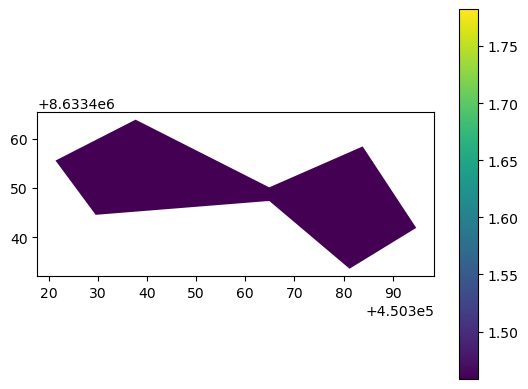

In [59]:
zam_filt.iloc[[2]].plot(column="shape_index", cmap="viridis", legend=True)